LOAD DATA

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/chennai_ecommerce_truckload_2024_Forecasting Truck load.xlsx")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

SECTION A — DATA EXPLORATION

Q1: Seasonal + Weekly Trends

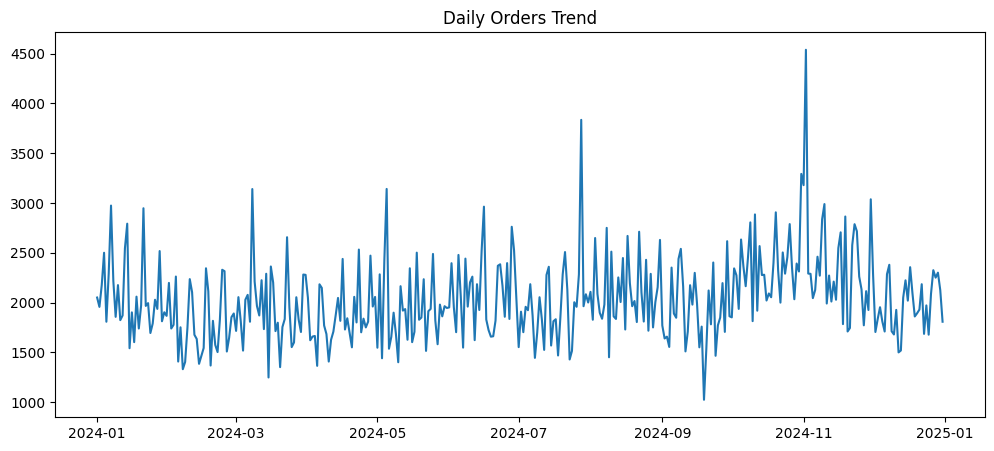

is_weekend
0    1917.683206
1    2331.038462
Name: orders_total, dtype: float64
is_festival_peak
0    2015.2
1    3231.5
Name: orders_total, dtype: float64


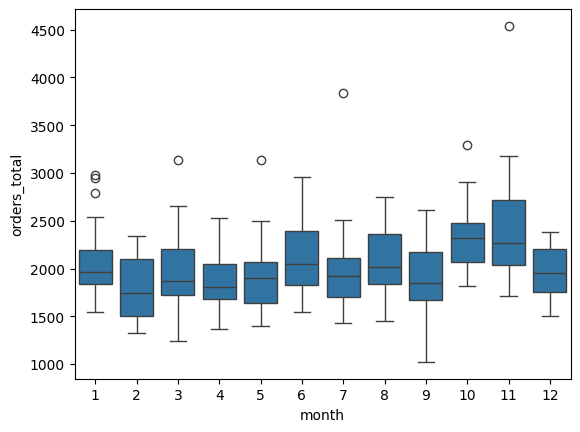

In [5]:
# Trend
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['orders_total'])
plt.title("Daily Orders Trend")
plt.show()

# Weekend vs weekday
print(df.groupby('is_weekend')['orders_total'].mean())

# Festival impact
print(df.groupby('is_festival_peak')['orders_total'].mean())

# Monthly trend
df['month'] = df['date'].dt.month
sns.boxplot(x='month', y='orders_total', data=df)
plt.show()




Q2: Rain Impact

In [6]:
rain_effect = df.groupby('rain_event')[[
    'orders_total',
    'trucks_required',
    'avg_route_distance_km'
]].mean()

print(rain_effect)

            orders_total  trucks_required  avg_route_distance_km
rain_event                                                      
0            2017.006780         2.877966              52.655513
1            2110.478873         3.042254              53.027124


Q3: Zone Analysis

In [7]:
zones = ['orders_north','orders_south','orders_central','orders_west']

print("Mean demand:\n", df[zones].mean())
print("\nVariability:\n", df[zones].std())

Mean demand:
 orders_north      622.614754
orders_south      587.245902
orders_central    437.874317
orders_west       387.404372
dtype: float64

Variability:
 orders_north      303.323656
orders_south      293.984157
orders_central    279.933976
orders_west       259.174761
dtype: float64


SECTION B — FORECASTING

Q4: Build Prediction Model

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

features = [
    'orders_total',
    'avg_volume_per_order_cuft',
    'rain_event',
    'rain_intensity_mm',
    'is_festival_peak',
    'orders_north','orders_south','orders_central','orders_west',
    'is_weekend'
]

X = df[features]
y = df['trucks_required']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

pred = model.predict(X_test)



Q5: Model Evaluation


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

rmse = np.sqrt(mean_squared_error(y_test, pred))
mape = mean_absolute_percentage_error(y_test, pred)

print("Random Forest RMSE:", rmse)
print("Random Forest MAPE:", mape)

Random Forest RMSE: 0.8034360332095266
Random Forest MAPE: 0.21173423423423424


Q6: Feature Importance

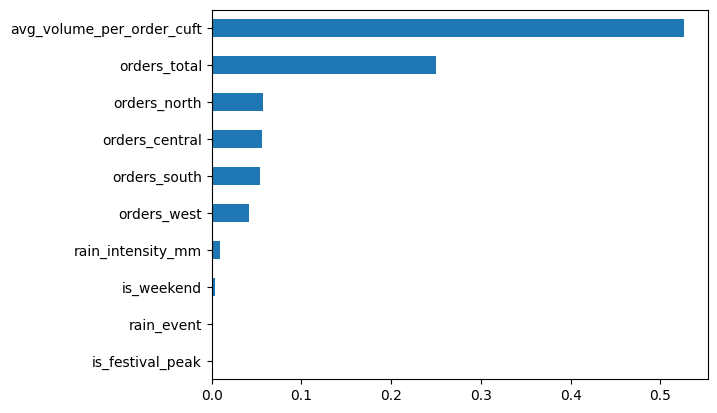

avg_volume_per_order_cuft    0.526562
orders_total                 0.250052
orders_north                 0.056638
orders_central               0.056383
orders_south                 0.053721
orders_west                  0.041793
rain_intensity_mm            0.009137
is_weekend                   0.003503
rain_event                   0.001896
is_festival_peak             0.000315
dtype: float64


In [10]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')
plt.show()

print(importance.sort_values(ascending=False))

SECTION C — FLEET OPTIMIZATION

Q7: Fixed vs Dynamic Allocation

Fixed:

In [11]:
zone_avg = df[zones].mean()
total = zone_avg.sum()

fixed_alloc = (zone_avg / total) * df['trucks_required'].mean()
print(fixed_alloc)

orders_north      0.890213
orders_south      0.839642
orders_central    0.626071
orders_west       0.553910
dtype: float64


Dynamic:

In [12]:
def dynamic_alloc(row):
    total = row[zones].sum()
    return (row[zones] / total) * row['trucks_required']

dynamic = df.apply(dynamic_alloc, axis=1)
print(dynamic.head())

   orders_north  orders_south  orders_central  orders_west
0      0.757073      0.299512        0.636098     0.307317
1      1.697853      0.769939        0.245399     0.286810
2      0.847886      0.430147        1.182904     0.539062
3      0.752000      0.789600        0.373600     0.084800
4      0.579967      1.824018        0.584394     1.011621


Q8: Cube Utilization

In [13]:
df['truck_capacity'] = 380

df['used_volume'] = df['volume_for_trucks_cuft']
df['total_capacity'] = df['trucks_required'] * df['truck_capacity']

df['utilization'] = df['used_volume'] / df['total_capacity']

print("Average Utilization:", df['utilization'].mean())

Average Utilization: 0.6553708908232077


SECTION D — SCENARIO ANALYSIS

Q9: Diwali (+25%)

In [14]:
df['diwali_trucks'] = df['trucks_required'] * 1.25
print("Avg trucks during Diwali:", df['diwali_trucks'].mean())

Avg trucks during Diwali: 3.637295081967213


Q10: Bike Orders +15%

In [15]:
df['bike_increase'] = df['trucks_required'] * 0.9
print("New truck requirement:", df['bike_increase'].mean())

New truck requirement: 2.618852459016394


Q11: Heavy Rain (>50mm)

In [16]:
df['rain_adjusted'] = np.where(
    df['rain_intensity_mm'] > 50,
    df['trucks_required'] * 1.2,
    df['trucks_required']
)

print("Trucks needed in heavy rain:", df['rain_adjusted'].mean())

Trucks needed in heavy rain: 2.93224043715847


SECTION E — FINAL RECOMMENDATIONS

Q12: Own vs Rent

In [17]:
avg_trucks = df['trucks_required'].mean()
peak_trucks = df['trucks_required'].max()

print("Own:", int(avg_trucks))
print("Rent:", int(peak_trucks - avg_trucks))

Own: 2
Rent: 6
